# Induction Heads in Pythia: Localization, Causality, and Emergence Across Training and Scale

*Mechanistic interpretability with Hugging Face transformers and PyTorch.*

This notebook finds the induction circuit inside EleutherAI/pythia-160m, confirms its role by
ablation, follows its formation across training via Pythia's intermediate checkpoints, and asks
whether that timing is consistent across model sizes (70m–410m).

**Induction:** shown … [A][B] … [A], an induction head looks back to what followed [A] earlier
([B]) and copies it forward — how a model continues patterns it never saw in training. 

The detection and phase-transition results reproduce known findings. The ablation, per-head
developmental tracking, and cross-scale comparison are the extensions. 

## Environment Setup

In [1]:
!pip install -q --upgrade transformers

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device.upper()}")
print(f"torch {torch.__version__}")
if device == "cpu":
    print("WARNING: No GPU. Colab: Runtime > Change runtime type > T4 GPU. "
          "Kaggle: Settings > Accelerator > GPU T4.")
torch.manual_seed(0)
np.random.seed(0)

Device: CUDA
torch 2.10.0+cu128


## Part 1: Load the Model

Pythia is EleutherAI's open model suite, built for studying training dynamics. 
Loading with eager attention is required so attention weights are exposed.

In [2]:
MODEL_NAME = "EleutherAI/pythia-160m"

def load_pythia(revision="main"):
    """Load a Pythia checkpoint + tokenizer at a given training revision."""
    tok = AutoTokenizer.from_pretrained(MODEL_NAME, revision=revision)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        revision=revision,
        dtype=torch.float32,   
        attn_implementation="eager",
    ).to(device)
    model.eval()
    return model, tok

model, tokenizer = load_pythia("main")

n_layers = model.config.num_hidden_layers
n_heads = model.config.num_attention_heads
print(f"Loaded {MODEL_NAME}: {n_layers} layers x {n_heads} heads, "
      f"d_model={model.config.hidden_size}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded EleutherAI/pythia-160m: 12 layers x 12 heads, d_model=768


## Part 2: Does the Model Do Induction?

Before inspecting internals, confirm the behaviour exists. Feed random tokens, repeat them, and
measure prediction loss at each position. If induction is working, loss should fall sharply once
the sequence starts repeating. The second half is fully predictable from the first.

In [3]:
def make_repeated_sequence(seq_len=50, batch=8):
    """Random tokens [P], then the same tokens again -> [P][P]. Shape (batch, 2*seq_len)."""
    torch.manual_seed(0)     
    vocab = model.config.vocab_size
    rand = torch.randint(1000, vocab - 1000, (batch, seq_len), device=device)
    bos = torch.full((batch, 1), tokenizer.bos_token_id or 0, device=device)
    tokens = torch.cat([bos, rand, rand], dim=1)   #(batch, 1 + 2*seq_len)
    return tokens

@torch.no_grad()
def per_position_loss(tokens):
    """Cross-entropy at each position (predicting the next token)."""
    logits = model(tokens).logits                       #(b, T, vocab)
    logp = torch.log_softmax(logits[:, :-1], dim=-1)    #predictions for positions 1..T-1
    targets = tokens[:, 1:]                             #actual next tokens
    tok_logp = logp.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    return (-tok_logp).mean(0).cpu().numpy()            #avg over batch -> (T-1,)

seq_len = 50
tokens = make_repeated_sequence(seq_len=seq_len, batch=16)
loss_curve = per_position_loss(tokens)

first_half = loss_curve[:seq_len].mean()
second_half = loss_curve[seq_len + 1:].mean()
print(f"Mean loss, first occurrence : {first_half:.3f}")
print(f"Mean loss, repeated half    : {second_half:.3f}")
print(f"Induction drop (first - second): {first_half - second_half:.3f}  "
      f"(large positive => induction present)")

Mean loss, first occurrence : 24.414
Mean loss, repeated half    : 5.287
Induction drop (first - second): 19.127  (large positive => induction present)


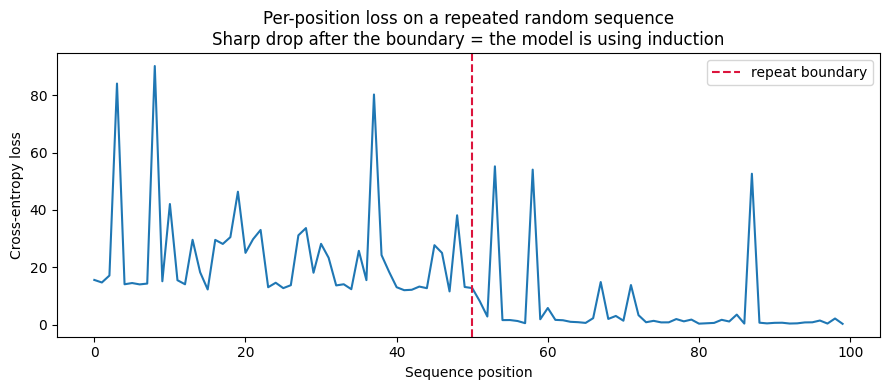

In [4]:
plt.figure(figsize=(9, 4))
plt.plot(loss_curve, lw=1.5)
plt.axvline(seq_len, color="crimson", ls="--", label="repeat boundary")
plt.xlabel("Sequence position")
plt.ylabel("Cross-entropy loss")
plt.title("Per-position loss on a repeated random sequence\n"
          "Sharp drop after the boundary = the model is using induction")
plt.legend()
plt.tight_layout()
plt.show()

## Part 3: Extracting Attention Patterns

The analysis needs the per-head attention probabilities for each layer and head, how strongly
every token attends to earlier ones. We pull these from the model's instrumented forward pass,
producing a (layers, batch, heads, query, key) tensor for Part 4 to score. 

In [5]:
@torch.no_grad()
def get_attentions(tokens):
    """Return attention patterns stacked over layers: (layers, batch, heads, query, key)."""
    out = model(tokens, output_attentions=True)
    return torch.stack(out.attentions, dim=0)

attn = get_attentions(tokens)
print("Attention tensor shape (layers, batch, heads, query, key):", tuple(attn.shape))

Attention tensor shape (layers, batch, heads, query, key): (12, 16, 12, 101, 101)


## Part 4: Which Heads Are Induction Heads?

Every attention head is scored by how much it attends to the induction target when reading the
repeated half. High-scoring heads are induction heads; the layer × head grid shows where the
behaviour lives inside the network.


In [6]:
@torch.no_grad()
def induction_scores(tokens, attn, seq_len):
    """Return (layers, heads) array of induction attention scores."""
    L, B, H, T, _ = attn.shape
    #induction offset: attend back to (matching token + 1) = period - 1 behind
    #second copy occupies positions [seq_len+1 .. 2*seq_len]; query t -> key t-seq_len+1... 
    #with BOS at pos 0, cleanest stripe is offset = seq_len
    offset = seq_len
    scores = torch.zeros(L, H, device=attn.device)
    count = 0
    # queries in repeated half
    for t in range(seq_len + 1, T):
        key = t - offset + 1            #induction target: token after the previous match
        if 0 <= key < T:
            scores += attn[:, :, :, t, key].mean(dim=1)  #mean over batch -> (L,H)
            count += 1
    return (scores / max(count, 1)).cpu().numpy()

ind = induction_scores(tokens, attn, seq_len)
print("Induction score grid shape (layers, heads):", ind.shape)

top = np.dstack(np.unravel_index(np.argsort(ind.ravel())[::-1][:5], ind.shape))[0]
print("\nTop induction heads (layer, head, score):")
for l, h in top:
    print(f"  layer {l:2d}  head {h:2d}   score = {ind[l, h]:.3f}")

Induction score grid shape (layers, heads): (12, 12)

Top induction heads (layer, head, score):
  layer  4  head  6   score = 0.982
  layer  8  head  2   score = 0.936
  layer  4  head 10   score = 0.911
  layer  5  head  0   score = 0.794
  layer  5  head  6   score = 0.752


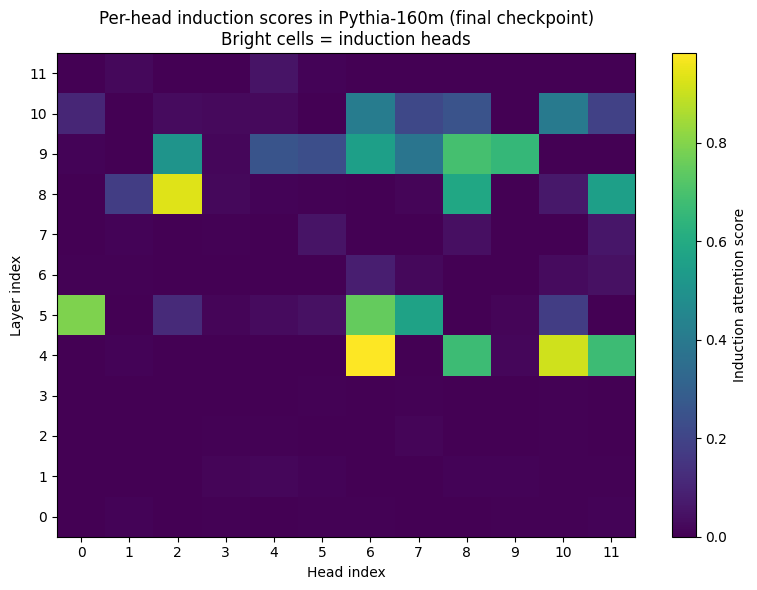

In [7]:
plt.figure(figsize=(8, 6))
im = plt.imshow(ind, aspect="auto", cmap="viridis", origin="lower")
plt.colorbar(im, label="Induction attention score")
plt.xlabel("Head index")
plt.ylabel("Layer index")
plt.title("Per-head induction scores in Pythia-160m (final checkpoint)\n"
          "Bright cells = induction heads")
plt.xticks(range(n_heads))
plt.yticks(range(n_layers))
plt.tight_layout()
plt.show()

## Part 5: When Does Induction Appear During Training?

Using Pythia's saved checkpoints, something no other model family offers at this density, the behavioural metric is re-run across training to see whether induction fades in gradually or switches on abruptly.

In [8]:
#densely sample early training to catch phase transition
CHECKPOINTS = ["step1", "step8", "step32", "step64", "step128",
               "step256", "step512", "step1000", "step8000", "step64000", "main"]

def quick_induction_drop(model_ckpt, seq_len=50, batch=16):
    """Cheap behavioural induction metric: first-half minus second-half loss."""
    torch.manual_seed(0)     
    vocab = model_ckpt.config.vocab_size
    rand = torch.randint(1000, vocab - 1000, (batch, seq_len), device=device)
    bos = torch.full((batch, 1), tokenizer.bos_token_id or 0, device=device)
    toks = torch.cat([bos, rand, rand], dim=1)
    with torch.no_grad():
        logits = model_ckpt(toks).logits
        logp = torch.log_softmax(logits[:, :-1], dim=-1)
        tlp = logp.gather(-1, toks[:, 1:].unsqueeze(-1)).squeeze(-1)
        curve = (-tlp).mean(0).cpu().numpy()
    return curve[:seq_len].mean() - curve[seq_len + 1:].mean()

steps, drops = [], []
for ckpt in CHECKPOINTS:
    print(f"Loading {ckpt} ...", flush=True)
    m, _ = load_pythia(ckpt)
    d = quick_induction_drop(m)
    step_num = 0 if ckpt == "main" else int(ckpt.replace("step", ""))
    if ckpt == "main":
        step_num = 143000  # final
    steps.append(step_num)
    drops.append(d)
    print(f"   {ckpt}: induction drop = {d:.3f}")
    del m
    torch.cuda.empty_cache()

order = np.argsort(steps)
steps = np.array(steps)[order]
drops = np.array(drops)[order]

Loading step1 ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

   step1: induction drop = 0.007
Loading step8 ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

   step8: induction drop = 0.006
Loading step32 ...


...

   step8000: induction drop = 13.107
Loading step64000 ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

   step64000: induction drop = 12.712
Loading main ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

   main: induction drop = 19.127


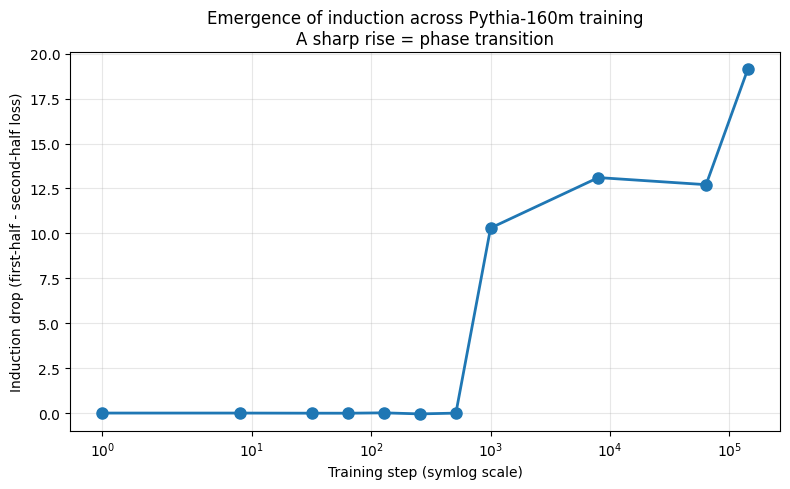

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(steps, drops, "o-", lw=2, ms=8)
plt.xscale("symlog")
plt.xlabel("Training step (symlog scale)")
plt.ylabel("Induction drop (first-half - second-half loss)")
plt.title("Emergence of induction across Pythia-160m training\n"
          "A sharp rise = phase transition")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 6: Are These Heads Actually Responsible?

Attention scores are correlational. To test causation the top heads are ablated (zeroing each head's contribution before the output projection, where heads remain separable) and it is tested how far the behaviour collapses: individually and as a group.


In [10]:
head_dim = model.config.hidden_size // n_heads

#correct ablation point: a PRE-hook on the attention output projection (`dense`)
#at dense's INPUT the per-head outputs are still laid out contiguously as (batch, seq, n_heads * head_dim) and have not yet been mixed by the projection
#zeroing head h's slice here removes exactly that head's contribution
def ablate_head_prehook(head_idx):
    def pre_hook(module, args):
        x = args[0].clone()
        start, end = head_idx * head_dim, (head_idx + 1) * head_dim
        x[:, :, start:end] = 0.0
        return (x,) + tuple(args[1:])
    return pre_hook

@torch.no_grad()
def induction_drop_with_ablation(ablate_list, seq_len=50, batch=16):
    """Induction drop with a set of (layer, head) ablations applied. Empty list = baseline."""
    handles = []
    for (l, h) in ablate_list:
        handles.append(
            model.gpt_neox.layers[l].attention.dense.register_forward_pre_hook(
                ablate_head_prehook(h)))
    try:
        toks = make_repeated_sequence(seq_len=seq_len, batch=batch)
        curve = per_position_loss(toks)
    finally:
        for hd in handles:
            hd.remove()
    return curve[:seq_len].mean() - curve[seq_len + 1:].mean()

baseline = induction_drop_with_ablation([])
print(f"Baseline induction drop (no ablation): {baseline:.3f}\n")

top_heads = [(int(l), int(h)) for l, h in top]
print("Ablating each top head individually:")
single = {}
for (l, h) in top_heads:
    d = induction_drop_with_ablation([(l, h)])
    single[(l, h)] = d
    print(f"  ablate L{l}H{h}: drop = {d:6.3f}   "
          f"({100*(baseline-d)/baseline:5.1f}% reduction)")

all_d = induction_drop_with_ablation(top_heads)
print(f"\nAblating ALL top heads together: drop = {all_d:.3f}   "
      f"({100*(baseline-all_d)/baseline:.1f}% reduction)")

Baseline induction drop (no ablation): 19.127

Ablating each top head individually:
  ablate L4H6: drop = 17.717   (  7.4% reduction)
  ablate L8H2: drop = 18.850   (  1.4% reduction)
  ablate L4H10: drop = 17.691   (  7.5% reduction)
  ablate L5H0: drop = 16.397   ( 14.3% reduction)
  ablate L5H6: drop = 18.443   (  3.6% reduction)

Ablating ALL top heads together: drop = 6.880   (64.0% reduction)


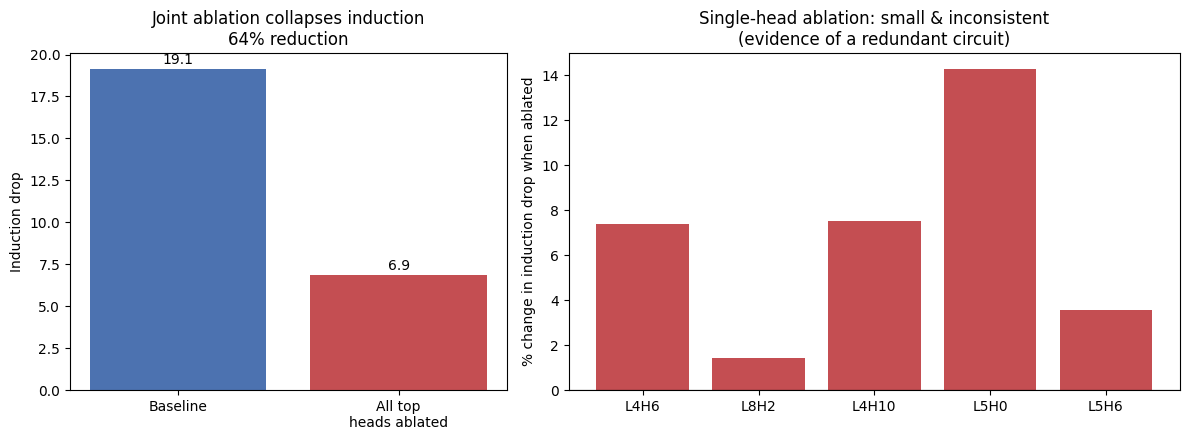

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5),
                               gridspec_kw={"width_ratios": [1, 1.4]})

ax1.bar(["Baseline", "All top\nheads ablated"], [baseline, all_d],
        color=["#4c72b0", "#c44e52"])
ax1.set_ylabel("Induction drop")
ax1.set_title(f"Joint ablation collapses induction\n"
              f"{100*(baseline-all_d)/baseline:.0f}% reduction")
for i, v in enumerate([baseline, all_d]):
    ax1.text(i, v + 0.3, f"{v:.1f}", ha="center")

labels = [f"L{l}H{h}" for (l, h) in top_heads]
reductions = [100*(baseline - single[(l, h)])/baseline for (l, h) in top_heads]
colors = ["#c44e52" if r > 0 else "#999999" for r in reductions]
ax2.bar(labels, reductions, color=colors)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("% change in induction drop when ablated")
ax2.set_title("Single-head ablation: small & inconsistent\n(evidence of a redundant circuit)")

plt.tight_layout()
plt.show()

## Part 7: Do the Heads Switch On at the Transition?

Linking Parts 4 and 5. Each top head's induction score is recomputed at every checkpoint and its trajectory is tracked to see whether the heads forming and the behaviour appearing are the same moment or whether the circuit assembles in stages.

In [12]:
TRACK_HEADS = [(int(l), int(h)) for l, h in top][:4]  

@torch.no_grad()
def head_scores_for_model(m, seq_len=50, batch=16):
    """Per-head induction score grid for a given model checkpoint."""
    torch.manual_seed(0)     
    vocab = m.config.vocab_size
    rand = torch.randint(1000, vocab - 1000, (batch, seq_len), device=device)
    bos = torch.full((batch, 1), tokenizer.bos_token_id or 0, device=device)
    toks = torch.cat([bos, rand, rand], dim=1)
    out = m(toks, output_attentions=True)
    a = torch.stack(out.attentions, dim=0)          # (L,B,H,T,T)
    L, B, H, T, _ = a.shape
    offset = seq_len
    scores = torch.zeros(L, H, device=a.device); count = 0
    for t in range(seq_len + 1, T):
        key = t - offset + 1
        if 0 <= key < T:
            scores += a[:, :, :, t, key].mean(dim=1); count += 1
    return (scores / max(count, 1)).cpu().numpy()

traj = {hh: [] for hh in TRACK_HEADS}
traj_steps = []
for ckpt in CHECKPOINTS:
    m, _ = load_pythia(ckpt)
    grid = head_scores_for_model(m)
    step_num = 143000 if ckpt == "main" else int(ckpt.replace("step", ""))
    traj_steps.append(step_num)
    for (l, h) in TRACK_HEADS:
        traj[(l, h)].append(grid[l, h])
    print(f"{ckpt:>8}: " + "  ".join(f"L{l}H{h}={grid[l,h]:.2f}" for (l,h) in TRACK_HEADS))
    del m; torch.cuda.empty_cache()

order = np.argsort(traj_steps)
traj_steps = np.array(traj_steps)[order]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

   step1: L4H6=0.01  L8H2=0.01  L4H10=0.01  L5H0=0.01


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

   step8: L4H6=0.01  L8H2=0.01  L4H10=0.01  L5H0=0.01


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

step8000: L4H6=0.98  L8H2=0.19  L4H10=0.93  L5H0=0.64


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

step64000: L4H6=0.98  L8H2=0.65  L4H10=0.89  L5H0=0.78


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

    main: L4H6=0.98  L8H2=0.94  L4H10=0.91  L5H0=0.79


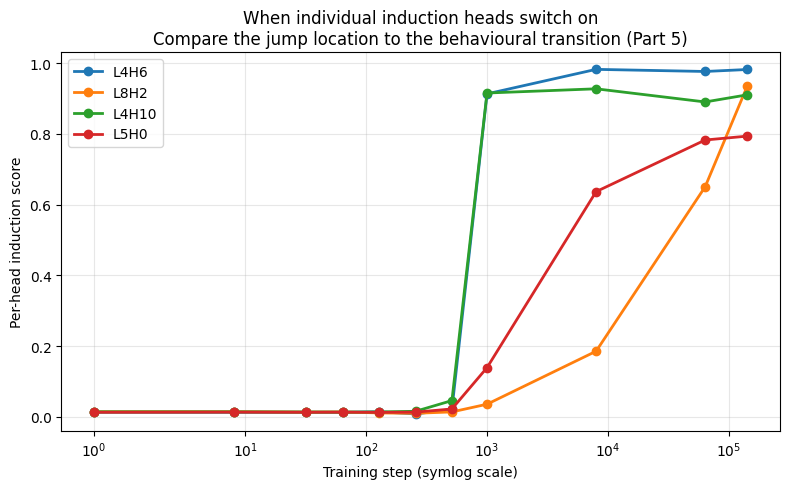

In [13]:
plt.figure(figsize=(8, 5))
for (l, h) in TRACK_HEADS:
    y = np.array(traj[(l, h)])[order]
    plt.plot(traj_steps, y, "o-", lw=2, ms=6, label=f"L{l}H{h}")
plt.xscale("symlog")
plt.xlabel("Training step (symlog scale)")
plt.ylabel("Per-head induction score")
plt.title("When individual induction heads switch on\n"
          "Compare the jump location to the behavioural transition (Part 5)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 8: Does the Timing Hold Across Model Size?

We repeat the emergence sweep on 70m, 160m, and 410m. The question: do larger models acquire induction at a different point in training, or is the onset step shared across scale?


In [14]:
SCALE_MODELS = ["EleutherAI/pythia-70m",
                "EleutherAI/pythia-160m",
                "EleutherAI/pythia-410m"]
SCALE_CKPTS = ["step256", "step512", "step1000", "step2000", "step8000", "main"]

def load_named(name, revision):
    tok = AutoTokenizer.from_pretrained(name, revision=revision)
    m = AutoModelForCausalLM.from_pretrained(
        name, revision=revision, dtype=torch.float32,
        attn_implementation="eager").to(device)
    m.eval()
    return m, tok

@torch.no_grad()
def drop_for(m, tok, seq_len=50, batch=16):
    torch.manual_seed(0)     
    vocab = m.config.vocab_size
    rand = torch.randint(1000, vocab - 1000, (batch, seq_len), device=device)
    bos = torch.full((batch, 1), tok.bos_token_id or 0, device=device)
    toks = torch.cat([bos, rand, rand], dim=1)
    logits = m(toks).logits
    logp = torch.log_softmax(logits[:, :-1], dim=-1)
    tlp = logp.gather(-1, toks[:, 1:].unsqueeze(-1)).squeeze(-1)
    curve = (-tlp).mean(0).cpu().numpy()
    return curve[:seq_len].mean() - curve[seq_len + 1:].mean()

scale_results = {}
for name in SCALE_MODELS:
    drops_s, steps_s = [], []
    print(f"\n=== {name} ===")
    for ckpt in SCALE_CKPTS:
        m, tok = load_named(name, ckpt)
        d = drop_for(m, tok)
        step_num = 143000 if ckpt == "main" else int(ckpt.replace("step", ""))
        drops_s.append(d); steps_s.append(step_num)
        print(f"  {ckpt:>8}: drop = {d:6.3f}")
        del m; torch.cuda.empty_cache()
    o = np.argsort(steps_s)
    scale_results[name] = (np.array(steps_s)[o], np.array(drops_s)[o])


=== EleutherAI/pythia-70m ===


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

   step256: drop =  0.042


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

   step512: drop =  0.046


...

  step2000: drop = 12.431


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

  step8000: drop = 12.888


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

      main: drop = 12.532


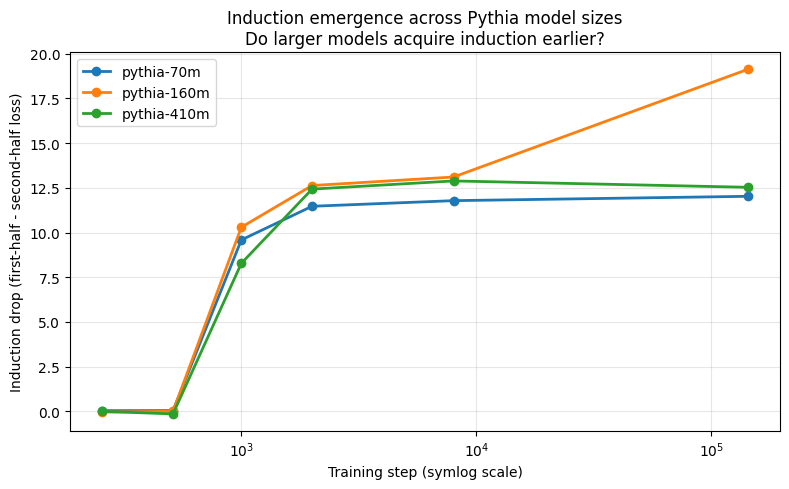

In [15]:
plt.figure(figsize=(8, 5))
for name, (s, d) in scale_results.items():
    short = name.split("/")[-1]
    plt.plot(s, d, "o-", lw=2, ms=6, label=short)
plt.xscale("symlog")
plt.xlabel("Training step (symlog scale)")
plt.ylabel("Induction drop (first-half - second-half loss)")
plt.title("Induction emergence across Pythia model sizes\n"
          "Do larger models acquire induction earlier?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

For the Pythia family, this notebook establishes:

- **Behaviour**: induction is strongly present (a large drop in prediction loss on repeated
  sequences).
- **Localization**: it is carried by a few mid-layer attention heads (Part 4).
- **Causality**: ablating those heads together collapses the behaviour, while removing any single
  head barely affects it- the circuit is redundant (Part 6).
- **Development**: the layer-4 heads switch on exactly at the behavioural phase transition, with
  other heads recruited later, so the circuit assembles in stages (Parts 5, 7).
- **Scale**: the onset window is roughly the same across 70m, 160m, and 410m (Part 8).

A reproduction of the known induction phase transition, extended with causal, developmental, and
cross-scale analysis. 
Full findings, limitations, and figures are in the README.